In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
filename = r"C:\Users\ASUS\MMDP\BharatWeather_Trends.csv"
df = pd.read_csv(filename)

In [3]:
df.head()

,Date,Time,City,Temperature,Humidity,Wind Speed,Weather
0,2025-03-09,13:05:24,Delhi,31.51,11,1.43,clear sky
1,2025-03-09,13:05:26,Mumbai,30.50,41,4.88,clear sky
2,2025-03-09,13:05:28,Kolkata,32.62,26,2.56,clear sky
3,2025-03-09,13:05:30,Chennai,29.25,51,5.22,clear sky
4,2025-03-09,13:05:32,Bengaluru,33.43,13,4.65,broken clouds


In [4]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.drop(columns=['Date', 'Time'])

In [5]:
print("Dataset Summary:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

Dataset Summary:
        Temperature    Humidity  Wind Speed                       Datetime
count   140.000000  140.000000  140.000000                            140
mean     32.780500   18.364286    2.781000  2025-03-09 13:09:27.164285696
min      29.220000    8.000000    0.140000            2025-03-09 13:05:24
25%      31.645000   11.000000    1.845000     2025-03-09 13:07:10.500000
50%      33.190000   12.000000    2.560000            2025-03-09 13:09:27
75%      33.710000   17.250000    4.040000  2025-03-09 13:11:43.750000128
max      37.100000   56.000000    5.220000            2025-03-09 13:13:31
std       1.919164   13.510034    1.411349                            NaN

Missing Values:
 City           0
Temperature    0
Humidity       0
Wind Speed     0
Weather        0
Datetime       0
dtype: int64


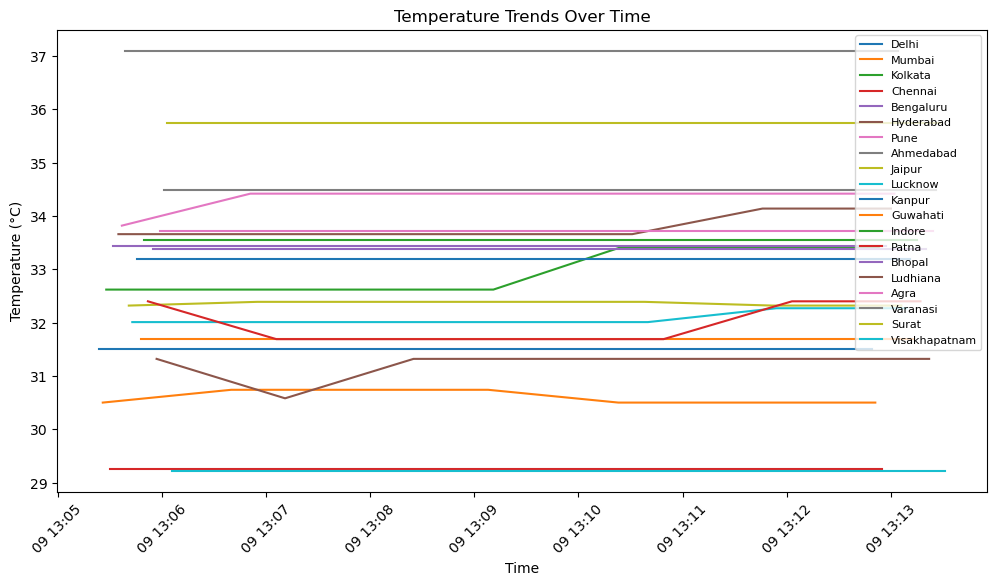

In [7]:
# Plot 1: Temperature Trends Over Time for Major Cities
plt.figure(figsize=(12, 6))
for city in df['City'].unique():
    city_data = df[df['City'] == city]
    plt.plot(city_data['Datetime'], city_data['Temperature'], label=city)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Trends Over Time")
plt.legend(loc="best", fontsize=8)
plt.xticks(rotation=45)
plt.show()


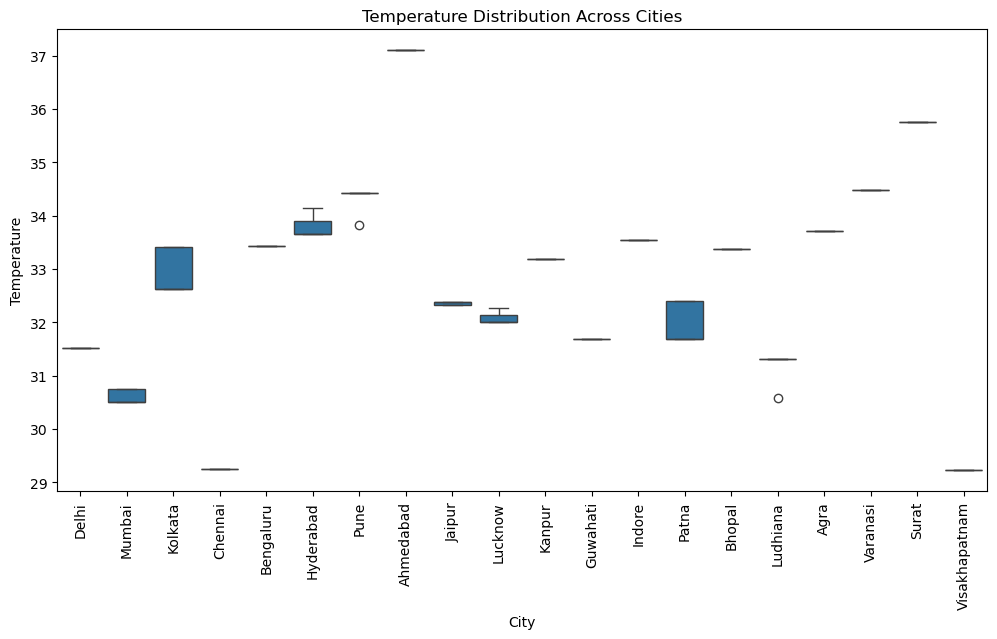

In [12]:
# Plot 2: Boxplot of Temperature Distribution Across Cities
plt.figure(figsize=(12, 6))
sns.boxplot(x="City", y="Temperature", data=df)
plt.xticks(rotation=90)
plt.title("Temperature Distribution Across Cities")
plt.show()

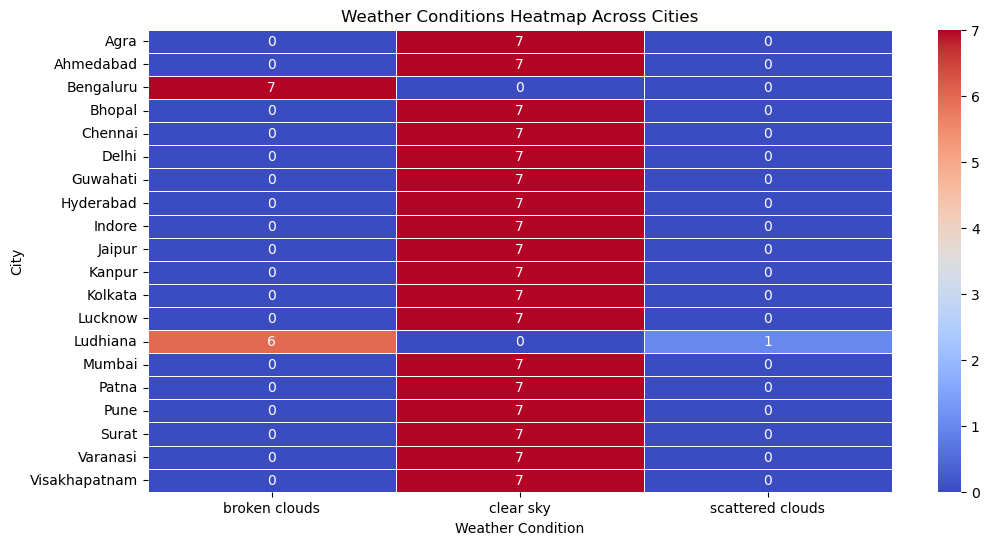

In [13]:
# Plot 3: Heatmap of Weather Conditions Across Cities
weather_counts = df.groupby(['City', 'Weather']).size().unstack().fillna(0)
plt.figure(figsize=(12, 6))
sns.heatmap(weather_counts, cmap="coolwarm", linewidths=0.5, annot=True, fmt=".0f")
plt.title("Weather Conditions Heatmap Across Cities")
plt.xlabel("Weather Condition")
plt.ylabel("City")
plt.show()

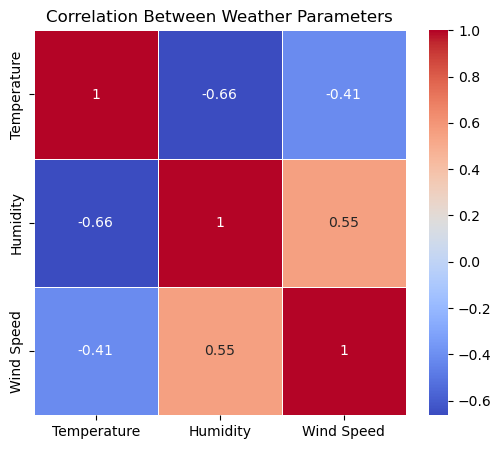

In [14]:
# Plot 4: Correlation Heatmap Between Weather Attributes
weather_numeric = df[['Temperature', 'Humidity', 'Wind Speed']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(weather_numeric, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Weather Parameters")
plt.show()

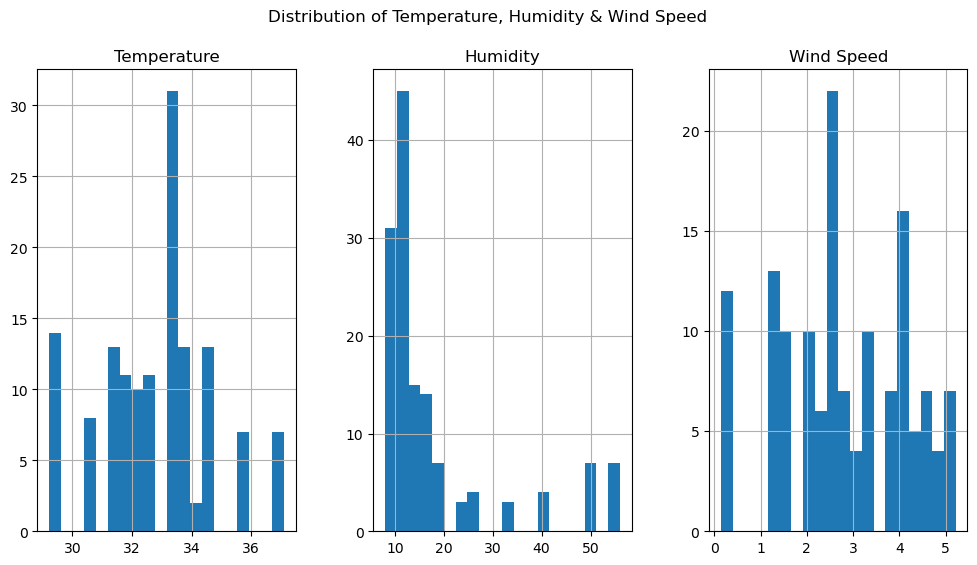

In [15]:
# Plot 5: Histogram of Temperature, Humidity & Wind Speed
df[['Temperature', 'Humidity', 'Wind Speed']].hist(bins=20, figsize=(12, 6), layout=(1, 3))
plt.suptitle("Distribution of Temperature, Humidity & Wind Speed")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22632\3761924873.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_temps.index, y=avg_temps.values, palette="coolwarm")


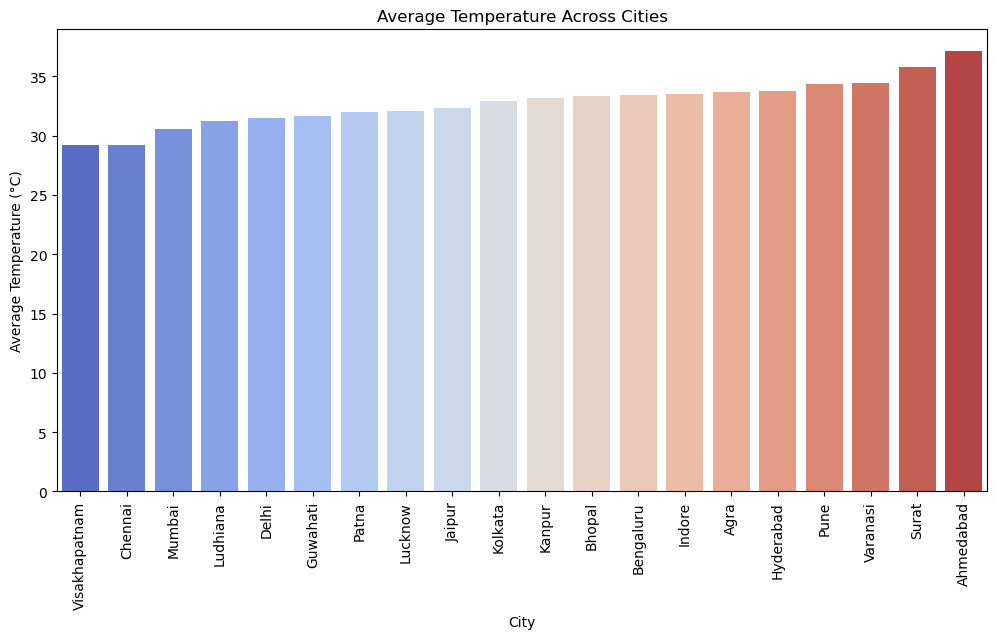

In [16]:
# Plot 6: Average Temperature per City
plt.figure(figsize=(12, 6))
avg_temps = df.groupby("City")["Temperature"].mean().sort_values()
sns.barplot(x=avg_temps.index, y=avg_temps.values, palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Average Temperature Across Cities")
plt.xlabel("City")
plt.ylabel("Average Temperature (°C)")
plt.show()

In [17]:
print("\nTop 5 Hottest Cities:\n", df.groupby('City')['Temperature'].max().sort_values(ascending=False).head())
print("\nTop 5 Coldest Cities:\n", df.groupby('City')['Temperature'].min().sort_values().head())


Top 5 Hottest Cities:
 City
Ahmedabad    37.10
Surat        35.75
Varanasi     34.48
Pune         34.42
Hyderabad    34.14
Name: Temperature, dtype: float64

Top 5 Coldest Cities:
 City
Visakhapatnam    29.22
Chennai          29.25
Mumbai           30.50
Ludhiana         30.58
Delhi            31.51
Name: Temperature, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22632\1890021921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="City", y="Humidity", palette="Blues_d")


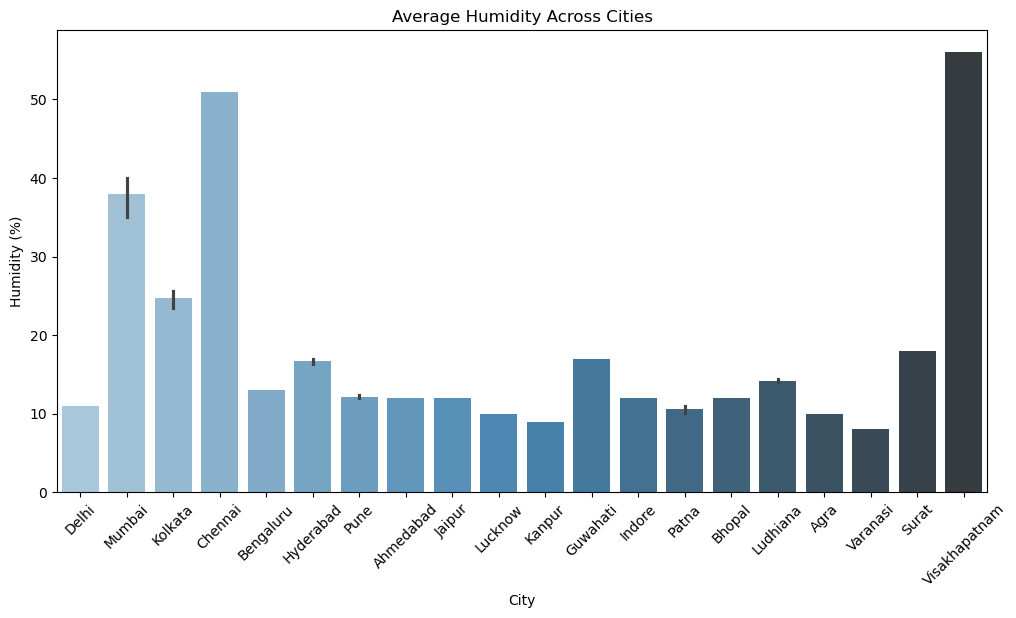

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="City", y="Humidity", palette="Blues_d")
plt.xticks(rotation=45)
plt.title("Average Humidity Across Cities")
plt.ylabel("Humidity (%)")
plt.show()


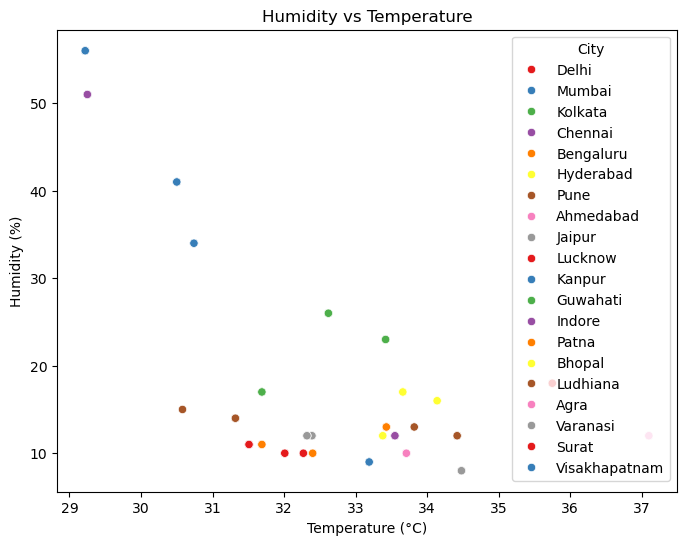

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Temperature", y="Humidity", hue="City", palette="Set1")
plt.title("Humidity vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.show()


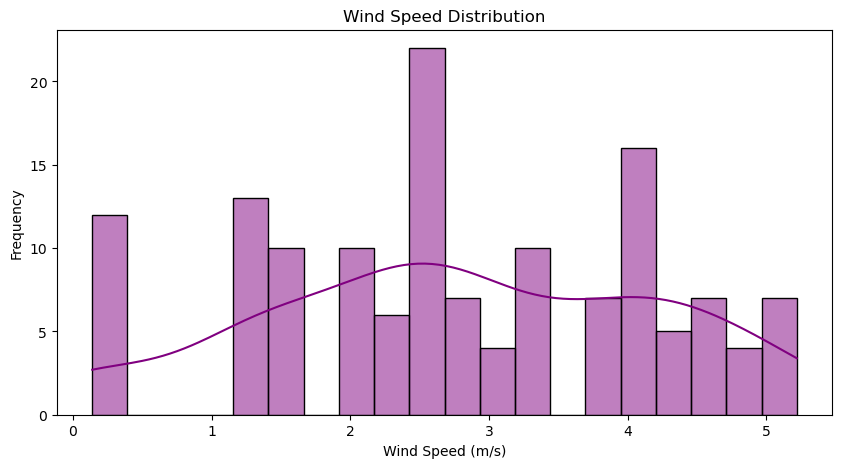

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Wind Speed"], bins=20, kde=True, color="purple")
plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.show()


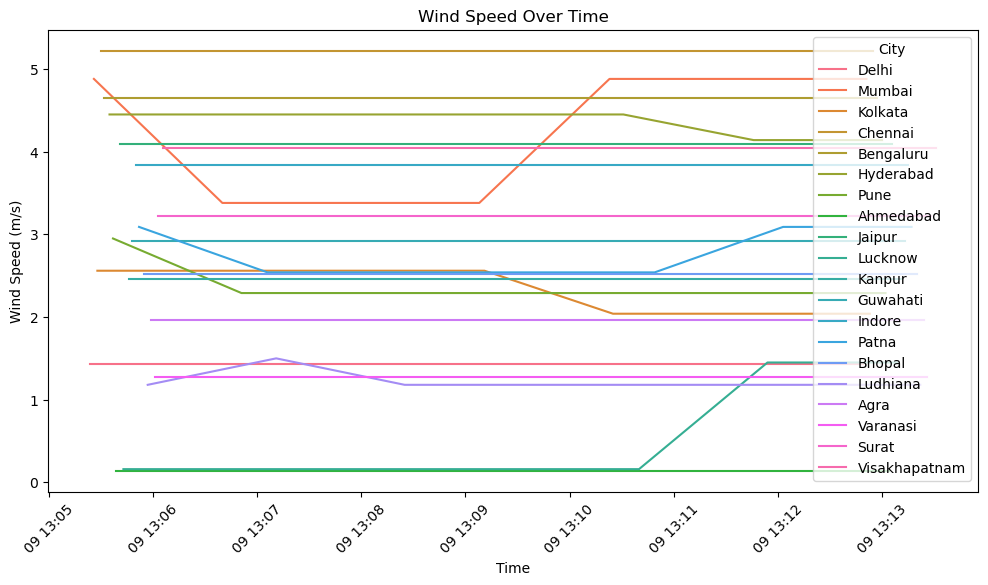

In [28]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Datetime", y="Wind Speed", hue="City")
plt.xticks(rotation=45)
plt.title("Wind Speed Over Time")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22632\2568316331.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Weather", order=df["Weather"].value_counts().index, palette="viridis")


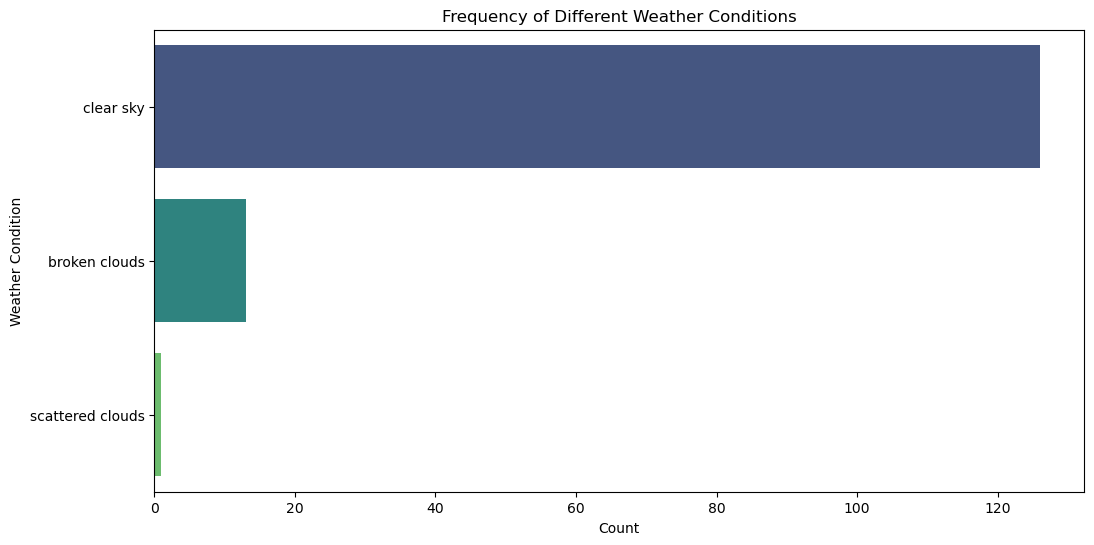

In [29]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y="Weather", order=df["Weather"].value_counts().index, palette="viridis")
plt.title("Frequency of Different Weather Conditions")
plt.xlabel("Count")
plt.ylabel("Weather Condition")
plt.show()


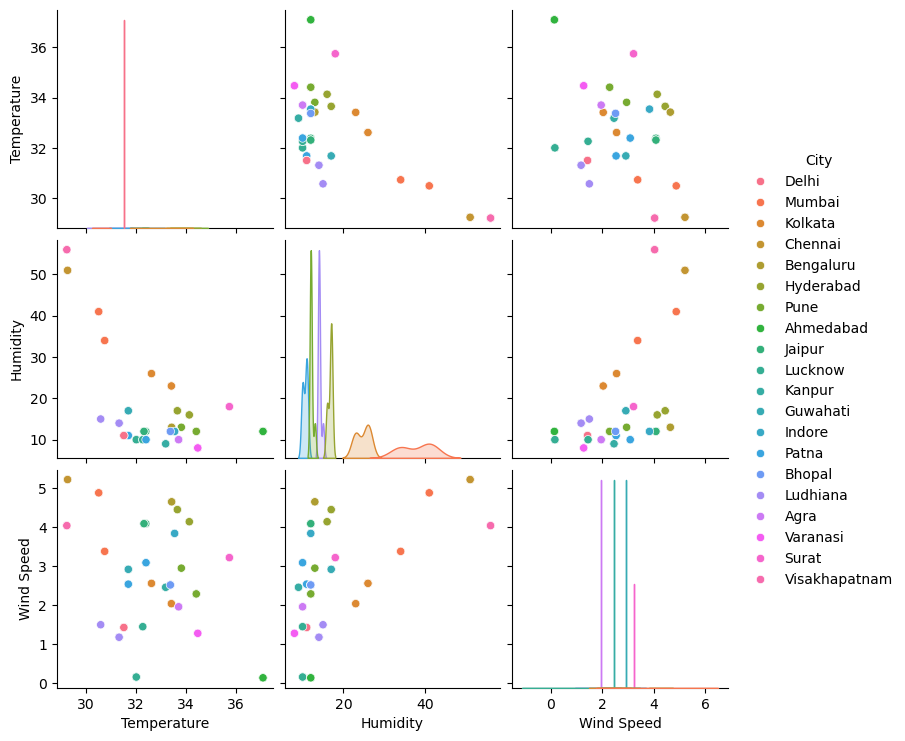

In [30]:
sns.pairplot(df, hue="City", vars=["Temperature", "Humidity", "Wind Speed"])
plt.show()


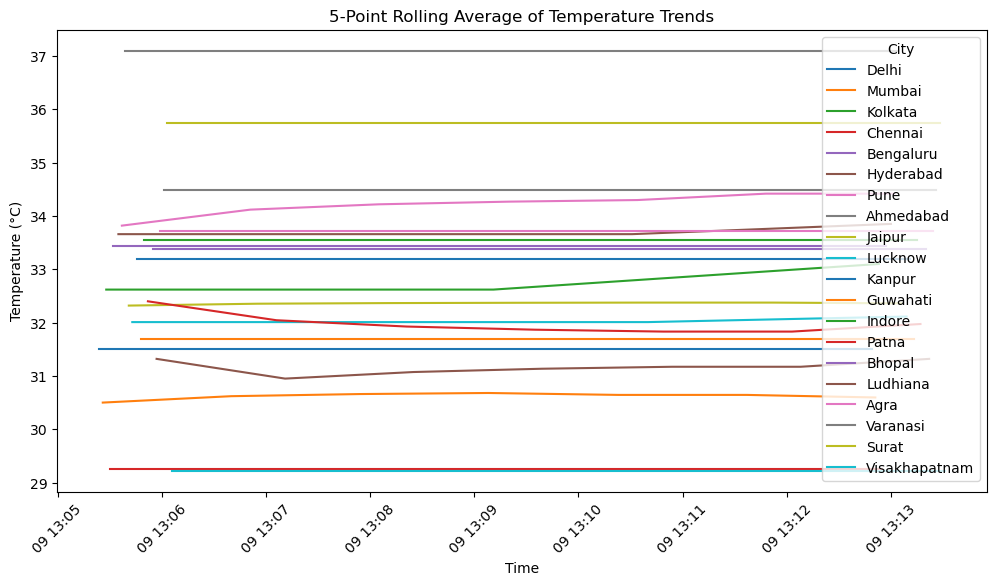

In [31]:
df['Rolling_Temp'] = df.groupby("City")["Temperature"].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Datetime", y="Rolling_Temp", hue="City", palette="tab10")
plt.xticks(rotation=45)
plt.title("5-Point Rolling Average of Temperature Trends")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22632\457486635.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="City", y="Temperature", palette="coolwarm", inner="quartile")


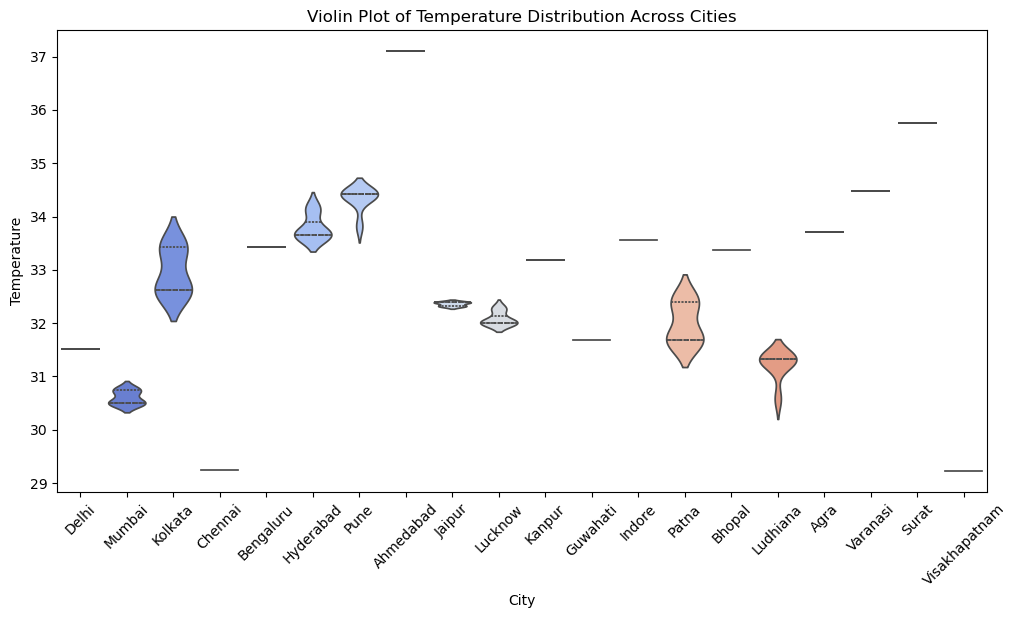

In [32]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x="City", y="Temperature", palette="coolwarm", inner="quartile")
plt.xticks(rotation=45)
plt.title("Violin Plot of Temperature Distribution Across Cities")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22632\1186300175.py:3: FutureWarning: The provided callable <function mean at 0x000001B9EB619BC0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  temp_pivot = df.pivot_table(index="City", columns="Datetime", values="Temperature", aggfunc=np.mean)


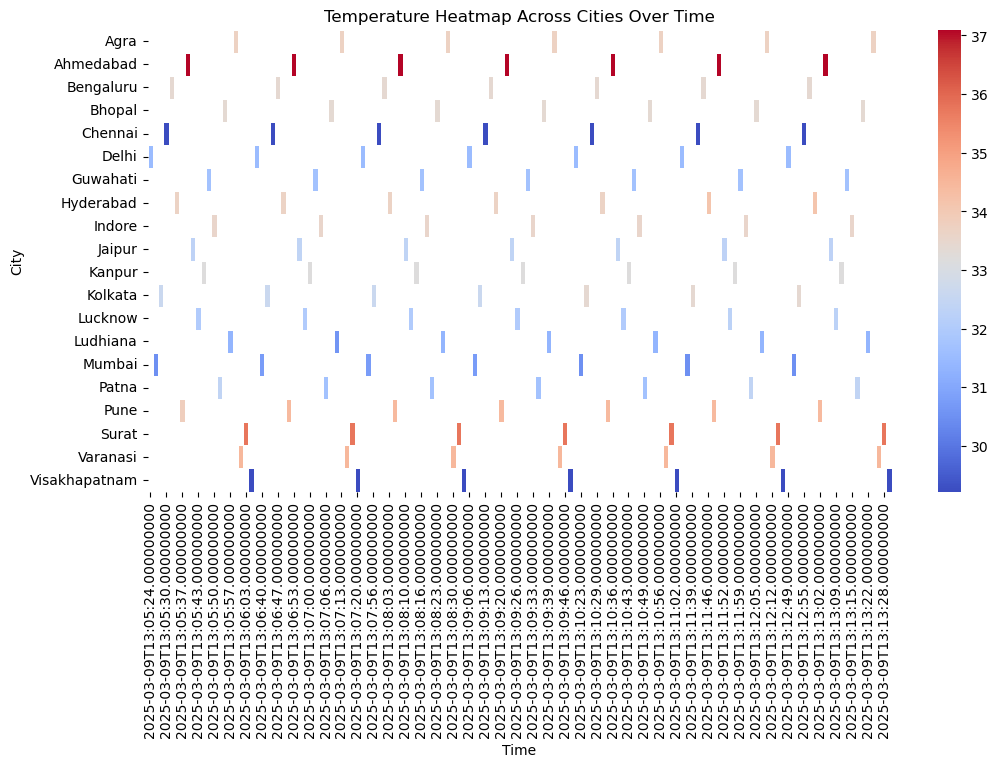

In [33]:
import numpy as np

temp_pivot = df.pivot_table(index="City", columns="Datetime", values="Temperature", aggfunc=np.mean)

plt.figure(figsize=(12, 6))
sns.heatmap(temp_pivot, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Temperature Heatmap Across Cities Over Time")
plt.xlabel("Time")
plt.ylabel("City")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22632\129874633.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["Wind Speed"], shade=True, color="purple")


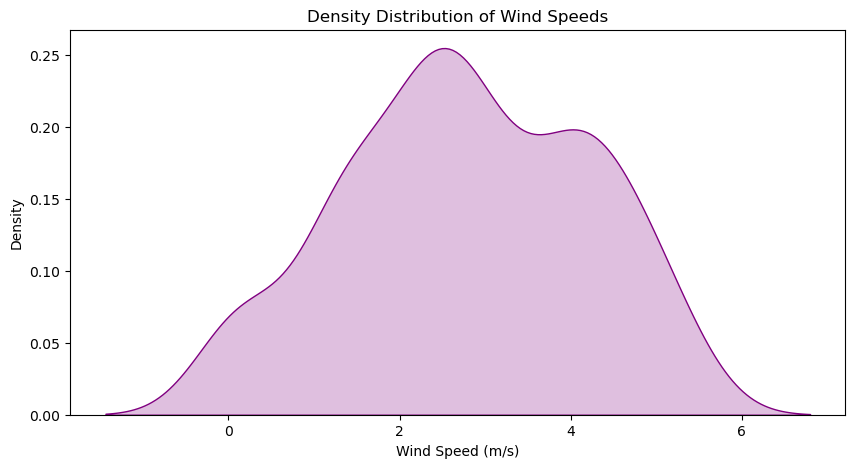

In [35]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df["Wind Speed"], shade=True, color="purple")
plt.title("Density Distribution of Wind Speeds")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Density")
plt.show()


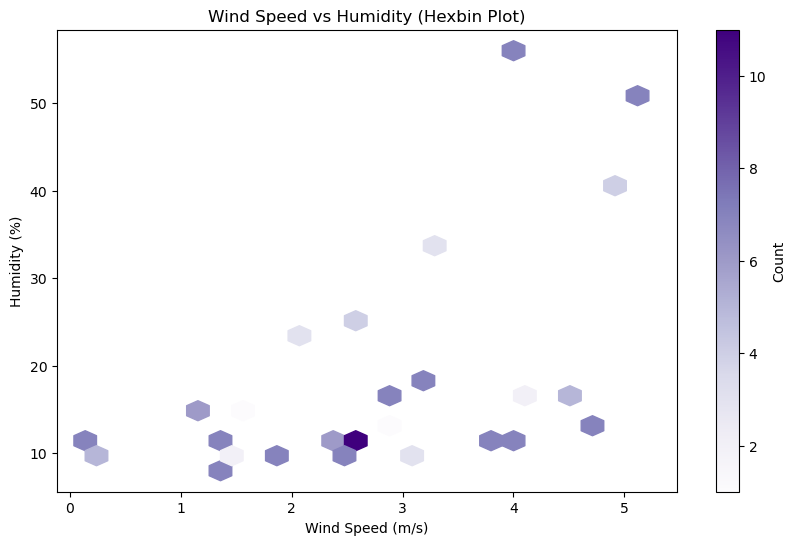

In [36]:
plt.figure(figsize=(10, 6))
plt.hexbin(df["Wind Speed"], df["Humidity"], gridsize=25, cmap="Purples", mincnt=1)
plt.colorbar(label="Count")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Humidity (%)")
plt.title("Wind Speed vs Humidity (Hexbin Plot)")
plt.show()


<Figure size 1200x600 with 0 Axes>

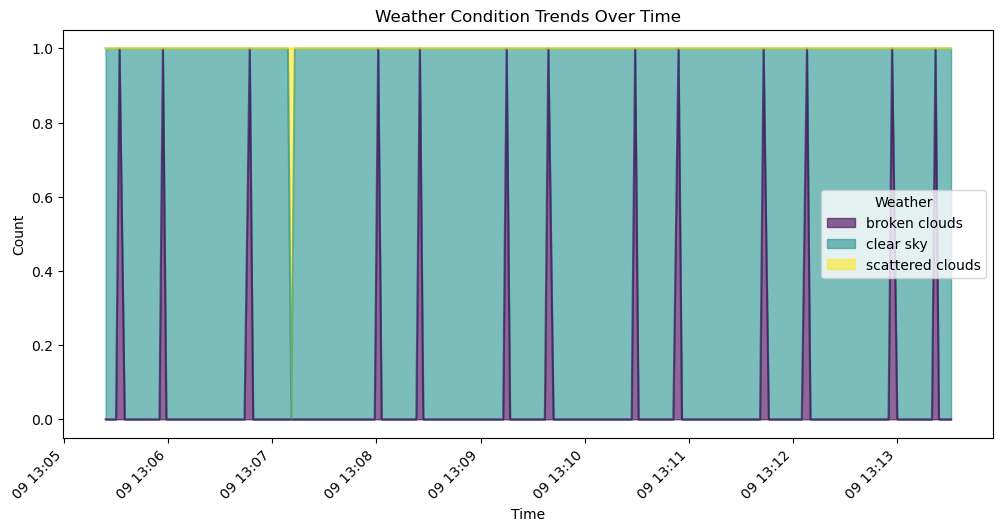

In [37]:
df['Weather'] = df['Weather'].astype(str)

plt.figure(figsize=(12, 6))
df.groupby(["Datetime", "Weather"]).size().unstack().plot(kind="area", stacked=True, figsize=(12, 6), colormap="viridis", alpha=0.6)
plt.xticks(rotation=45)
plt.title("Weather Condition Trends Over Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()


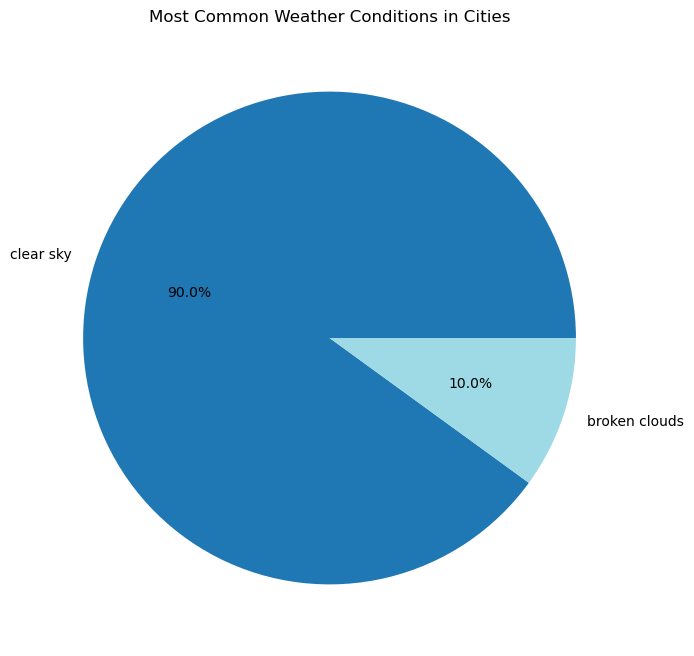

In [38]:
weather_counts = df.groupby("City")["Weather"].agg(lambda x: x.value_counts().idxmax())

plt.figure(figsize=(12, 6))
weather_counts.value_counts().plot(kind="pie", autopct="%1.1f%%", cmap="tab20", figsize=(8, 8))
plt.title("Most Common Weather Conditions in Cities")
plt.ylabel("")
plt.show()
